In [1]:
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms
from sklearn.metrics import confusion_matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cov_path = '/content/drive/MyDrive/COV/'

In [4]:
import os

drive_zip_path = '/content/drive/MyDrive/COV/images.zip'

local_zip_path = '/content/images.zip'
local_images_dir = '/content/images'

!cp "{drive_zip_path}" "{local_zip_path}"

os.makedirs(local_images_dir, exist_ok=True)

!unzip -q "{local_zip_path}" -d "{local_images_dir}"

print(f"'{drive_zip_path}' copied to '{local_zip_path}' and unzipped to '{local_images_dir}'")
print(f"Contents of {local_images_dir} (first 5 files):\n{os.listdir(local_images_dir)[:5]}")

'/content/drive/MyDrive/COV/images.zip' copied to '/content/images.zip' and unzipped to '/content/images'
Contents of /content/images (first 5 files):
['content']


In [5]:
os.listdir(os.getcwd())

['.config', 'drive', 'images.zip', 'images', 'sample_data']

In [6]:
!cp /content/drive/MyDrive/COV/data.csv /content/data.csv

In [7]:
df = pd.read_csv('data.csv')
# df['is_dog'] = (df['animal_type'] == 'dog').astype(int) # Remove this line as 'is_dog' is not needed for multiclass
df.head()

,image_id,animal_type,breed,global_breed_id,local_breed_id
0,Abyssinian_100,cat,abyssinian,1,1
1,Abyssinian_101,cat,abyssinian,1,1
2,Abyssinian_102,cat,abyssinian,1,1
3,Abyssinian_103,cat,abyssinian,1,1
4,Abyssinian_104,cat,abyssinian,1,1


In [8]:
df['global_breed_id'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37])

In [9]:
train_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    # transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2,
                               saturation=0.2,
                               contrast=0.2),
        transforms.RandomRotation(30),
    ], p=0.7),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [24]:
target = 'local_breed_id'

class AnimalDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.df.iloc[idx]['image_id'] + '.jpg')
        image = Image.open(img_name).convert('RGB')
        label = self.df.iloc[idx][target] - 1
        # label = self.df.iloc[idx]['is_dog']

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [81]:
df = pd.read_csv('data.csv')
df['is_dog'] = (df['animal_type'] == 'dog').astype(int)
# df = df[df['animal_type'] == 'cat']
# df = df[df['animal_type'] == 'dog']
df.head()

,image_id,animal_type,breed,global_breed_id,local_breed_id,is_dog
0,Abyssinian_100,cat,abyssinian,1,1,0
1,Abyssinian_101,cat,abyssinian,1,1,0
2,Abyssinian_102,cat,abyssinian,1,1,0
3,Abyssinian_103,cat,abyssinian,1,1,0
4,Abyssinian_104,cat,abyssinian,1,1,0


In [82]:
df['animal_type'].value_counts()

,count
animal_type,
dog,4978
cat,2371


In [84]:
from sklearn.model_selection import train_test_split

img_dir = '/content/images/content/drive/MyDrive/COV/images'

stratify_col = 'animal_type'
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=0, stratify=df[stratify_col])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=0, stratify=temp_df[stratify_col])

train_ds = AnimalDataset(train_df, img_dir, transform=train_trans)
val_ds = AnimalDataset(val_df, img_dir, transform=val_trans)
test_ds = AnimalDataset(test_df, img_dir, transform=val_trans)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)
val_loader = DataLoader(
    dataset=val_ds,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)
test_loader = DataLoader(
    dataset=test_ds,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)

In [85]:
for inputs, labels in test_loader:
  print(labels)
  break

tensor([ 2, 10,  8, 14,  9,  8, 17, 23,  9,  5,  4, 11,  0, 22, 19,  2, 20,  0,
         9, 24, 19,  9,  3,  6,  9, 19,  8, 13, 24,  1,  0, 12,  5,  5,  7, 10,
        24,  5, 10, 14,  5,  1, 12, 21,  6,  8,  0, 20, 23,  6,  2, 20, 15, 15,
         8, 16,  2,  6,  5, 21,  1,  5,  7,  1])


In [59]:
len(train_loader)

26

In [86]:
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

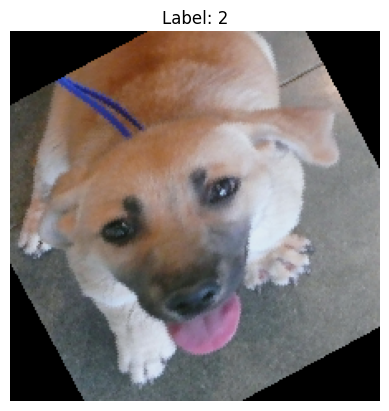

In [87]:
image, label = train_ds[53]
# label 3:
# 53
# 136
# 222
# 231
# 237
# 266
# 339
# 348
imshow(image, title=f"Label: {label}")

In [45]:
class CNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.pool = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.3)

    self.flatten = nn.Flatten()

    # Calculation for 224x224 input after 3 pools: 224/2/2/2 = 28
    # Feature vector: 128 * 28 * 28 = 100,352
    self.fc1 = nn.Linear(128 * 28 * 28, 256)
    self.fc2 = nn.Linear(256, num_classes)

  def forward(self, x):
    x = self.pool(self.relu(self.bn1(self.conv1(x))))
    x = self.pool(self.relu(self.bn2(self.conv2(x))))
    x = self.pool(self.relu(self.bn3(self.conv3(x))))

    x = self.flatten(x)

    x = self.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.fc2(x)

    return x

In [46]:
class CNN2(nn.Module):
  def __init__(self, num_classes=37):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32)

    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(256)

    self.pool = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU(inplace=True)

    # computes the mean within each adaptive region.
    self.gap = nn.AdaptiveAvgPool2d((1, 1))
    self.dropout = nn.Dropout(0.4)

    self.fc = nn.Sequential(
        nn.Linear(256, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(128, num_classes)
    )

  def forward(self, x):
    x = self.pool(self.relu(self.bn1(self.conv1(x)))) # 32x112x112 | 224 / 2
    x = self.pool(self.relu(self.bn2(self.conv2(x)))) # 64x56x56
    x = self.pool(self.relu(self.bn3(self.conv3(x)))) # 128x28x28
    x = self.pool(self.relu(self.bn4(self.conv4(x)))) # 256x14x14

    x = self.gap(x) # 256x1x1
    x = x.view(x.size(0), -1) # [Batch, 256]

    x = self.fc(x)
    return x

In [47]:
class Block(nn.Module):
  def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace=True)
    self.identity_downsample = identity_downsample

  def forward(self, x):
    identity = x
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)
    if self.identity_downsample is not None:
        identity = self.identity_downsample(identity)
    x += identity
    x = self.relu(x)
    return x

class CNN3(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.in_channels = 64
    self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU()
    self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    # residual layers
    self.layer1 = self.make_layer(64, 64, stride=1)
    self.layer2 = self.make_layer(64, 128, stride=2)
    self.layer3 = self.make_layer(128, 256, stride=2)
    self.layer4 = self.make_layer(256, 512, stride=2)

    self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512, num_classes)

  def make_layer(self, in_channels, out_channels, stride):
    identity_downsample = None
    if stride != 1:
      identity_downsample = self.identity_downsample(in_channels, out_channels)

    return nn.Sequential(
      Block(in_channels, out_channels, identity_downsample=identity_downsample, stride=stride),
      Block(out_channels, out_channels)
    )

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.max_pool(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avg_pool(x)
    x = x.view(x.shape[0], -1)
    x = self.fc(x)
    return x

  def identity_downsample(self, in_channels, out_channels):
    return nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
      nn.BatchNorm2d(out_channels)
    )

In [48]:
class BasicBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    # First Conv
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                            stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)

    # Second Conv
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                            stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.relu = nn.ReLU(inplace=True)

    # Shortcut connection to match dimensions if stride > 1
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
      self.shortcut = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
        nn.BatchNorm2d(out_channels)
      )

  def forward(self, x):
    identity = x

    out = self.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))

    out += self.shortcut(identity)
    out = self.relu(out)
    return out

class CNN4(nn.Module):
  def __init__(self, num_classes=37):
    super().__init__()
    self.in_channels = 64

    # Initial layer to process raw image
    self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace=True)
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    # ResNet Layers (Blocks of BasicBlocks)
    self.layer1 = self.make_layer(64,  1) # Output size: 56x56
    self.layer2 = self.make_layer(128, 2) # Output size: 28x28
    self.layer3 = self.make_layer(256, 2) # Output size: 14x14

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(256, num_classes)

  def make_layer(self, out_channels, stride):
    layer = BasicBlock(self.in_channels, out_channels, stride)
    self.in_channels = out_channels
    return layer

  def forward(self, x):
    x = self.maxpool(self.relu(self.bn1(self.conv1(x))))

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)

    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.fc(x)
    return x

In [49]:
class CNN5(nn.Module):
  def __init__(self, num_classes=37):
    super().__init__()

    self.block1 = nn.Sequential(
      nn.Conv2d(3, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.Conv2d(32, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2, 2)
    )

    self.block2 = nn.Sequential(
      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.Conv2d(64, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2, 2)
    )

    self.block3 = nn.Sequential(
      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace=True),
      nn.Dropout2d(0.1),
      nn.MaxPool2d(2, 2)
    )

    self.block4 = nn.Sequential(
      nn.Conv2d(128, 512, kernel_size=3, padding=1),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2, 2)
    )

    self.gap = nn.AdaptiveAvgPool2d((1, 1))

    self.fc = nn.Sequential(
      nn.Linear(512, 256),
      nn.ReLU(inplace=True),
      nn.Dropout(0.5),
      nn.Linear(256, num_classes)
    )

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)

    x = self.gap(x)
    x = torch.flatten(x, 1)

    x = self.fc(x)
    return x

In [50]:
model = CNN5(num_classes=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCEWithLogitsLoss()
# criterion = torch.nn.CrossEntropyLoss()

In [51]:
state_dict = torch.load(cov_path + 'dog_cnn5_model_ep300.pth')
model.load_state_dict(state_dict)

RuntimeError: Error(s) in loading state_dict for CNN5:
	size mismatch for fc.3.weight: copying a param with shape torch.Size([25, 256]) from checkpoint, the shape in current model is torch.Size([1, 256]).
	size mismatch for fc.3.bias: copying a param with shape torch.Size([25]) from checkpoint, the shape in current model is torch.Size([1]).

In [52]:
len(train_loader)

81

In [53]:
next(model.parameters()).device

device(type='cpu')

In [54]:
inputs, labels = next(iter(train_loader))
outputs = model(inputs)


In [ ]:
num_epochs = 300
device = 'cuda' if torch.cuda.is_available() else 'cpu'
history = {'train': {'acc': [], 'loss': []},
           'val': {'acc': [], 'loss': []}}
model.to(device)

for epoch in range(num_epochs):
  model.train()
  train_loss, train_correct, train_total = 0, 0, 0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)

    # binary
    outputs = outputs.squeeze()

    loss = criterion(outputs, labels.float())
    loss.backward()
    optimizer.step()

    train_loss += loss.item()

    # _, predicted = outputs.max(1)
    predicted = (torch.sigmoid(outputs) > 0.5).float()

    train_total += labels.size(0)
    train_correct += predicted.eq(labels).sum().item()

  model.eval()
  val_loss_epoch, val_correct, val_total = 0, 0, 0

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)

      # binary
      outputs = outputs.squeeze()

      loss = criterion(outputs, labels.float())

      val_loss_epoch += loss.item()

      # _, predicted = outputs.max(1)
      predicted = (torch.sigmoid(outputs) > 0.5).float()

      val_total += labels.size(0)
      val_correct += predicted.eq(labels).sum().item()

  history['train']['loss'].append(train_loss / len(train_loader))
  history['train']['acc'].append(train_correct / train_total)
  history['val']['loss'].append(val_loss_epoch / len(val_loader))
  history['val']['acc'].append(val_correct / val_total)

  print(f'Epoch {epoch+1}: Train Acc: {history["train"]["acc"][-1]:.2f} | Val Acc: {history["val"]["acc"][-1]:.2f}')

Epoch 1: Train Acc: 0.67 | Val Acc: 0.69
Epoch 2: Train Acc: 0.67 | Val Acc: 0.68
Epoch 3: Train Acc: 0.68 | Val Acc: 0.63
Epoch 4: Train Acc: 0.69 | Val Acc: 0.70
Epoch 5: Train Acc: 0.69 | Val Acc: 0.70
Epoch 6: Train Acc: 0.69 | Val Acc: 0.70
Epoch 7: Train Acc: 0.70 | Val Acc: 0.70
Epoch 8: Train Acc: 0.70 | Val Acc: 0.70
Epoch 9: Train Acc: 0.71 | Val Acc: 0.69
Epoch 10: Train Acc: 0.71 | Val Acc: 0.72
Epoch 11: Train Acc: 0.71 | Val Acc: 0.68
Epoch 12: Train Acc: 0.73 | Val Acc: 0.71
Epoch 13: Train Acc: 0.73 | Val Acc: 0.71
Epoch 14: Train Acc: 0.74 | Val Acc: 0.72
Epoch 15: Train Acc: 0.75 | Val Acc: 0.74
Epoch 16: Train Acc: 0.75 | Val Acc: 0.63
Epoch 17: Train Acc: 0.76 | Val Acc: 0.76
Epoch 18: Train Acc: 0.77 | Val Acc: 0.64
Epoch 19: Train Acc: 0.77 | Val Acc: 0.68
Epoch 20: Train Acc: 0.77 | Val Acc: 0.79
Epoch 21: Train Acc: 0.79 | Val Acc: 0.63
Epoch 22: Train Acc: 0.79 | Val Acc: 0.78
Epoch 23: Train Acc: 0.80 | Val Acc: 0.77
Epoch 24: Train Acc: 0.81 | Val Acc: 0.81
E

KeyboardInterrupt: 

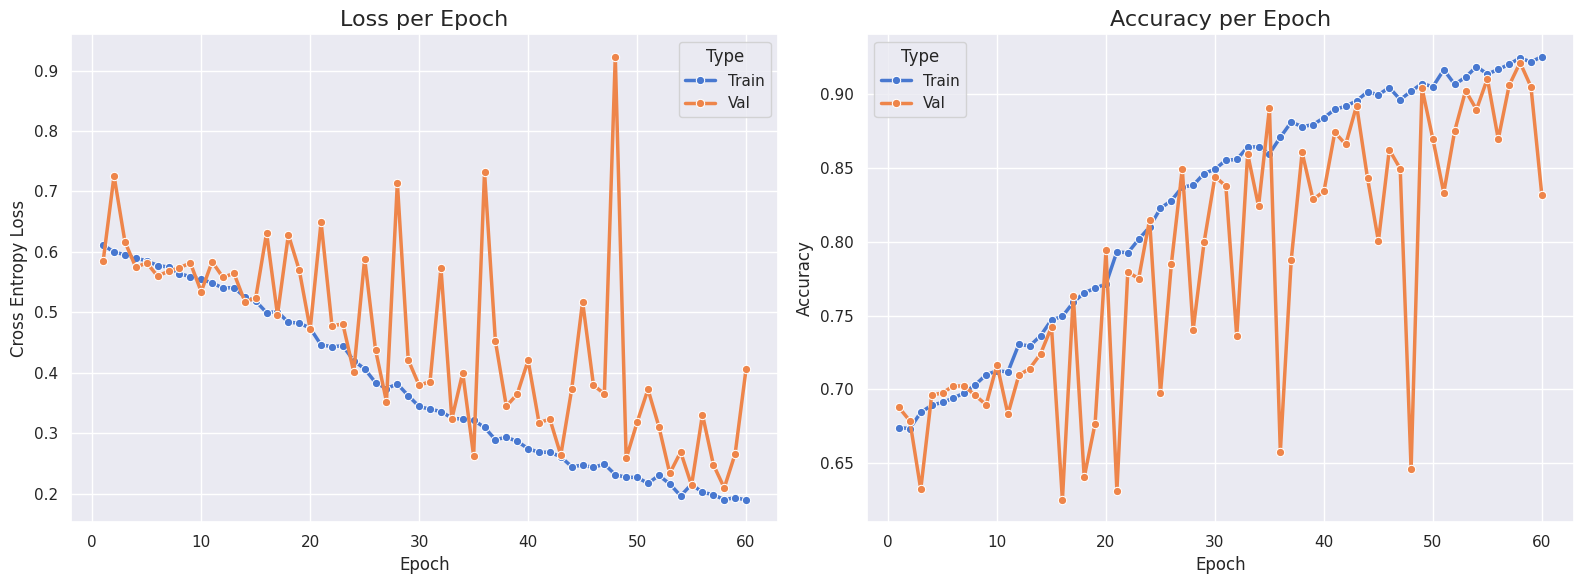

In [ ]:
def save_training_plots(history):
  epochs = list(range(1, len(history['train']['loss']) + 1))

  df_loss = pd.DataFrame({
      'Epoch': epochs * 2,
      'Loss': history['train']['loss'] + history['val']['loss'],
      'Type': ['Train'] * len(epochs) + ['Val'] * len(epochs)
  })

  df_acc = pd.DataFrame({
      'Epoch': epochs * 2,
      'Accuracy': [a for a in history['train']['acc']] + [a for a in history['val']['acc']],
      'Type': ['Train'] * len(epochs) + ['Val'] * len(epochs)
  })

  sns.set_theme(style="darkgrid", palette="muted")
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  sns.lineplot(ax=axes[0], data=df_loss, x='Epoch', y='Loss', hue='Type', marker='o', linewidth=2.5)
  axes[0].set_title('Loss per Epoch', fontsize=16)
  axes[0].set_ylabel('Cross Entropy Loss')

  sns.lineplot(ax=axes[1], data=df_acc, x='Epoch', y='Accuracy', hue='Type', marker='o', linewidth=2.5)
  axes[1].set_title('Accuracy per Epoch', fontsize=16)
  axes[1].set_ylabel('Accuracy')

  plt.tight_layout()
  plt.savefig('/content/drive/MyDrive/COV/binary_cnn2.png', dpi=300, bbox_inches='tight')

  plt.show()

save_training_plots(history)

In [ ]:
torch.save(model.state_dict(), cov_path + 'binary_cnn2_model_ep60.pth')

In [61]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [69]:
df['local_breed_id'].unique().size

25

In [70]:
binary_model = CNN2(num_classes=1)
cat_model = CNN5(num_classes=12)
dog_model = CNN5(num_classes=25)

binary_model_state_dict = torch.load(cov_path + 'binary_cnn2_model_ep60.pth')
cat_model_state_dict = torch.load(cov_path + 'cat_cnn5_model_ep300.pth')
dog_model_state_dict = torch.load(cov_path + 'dog_cnn5_model_ep300.pth')

binary_model.load_state_dict(binary_model_state_dict)
cat_model.load_state_dict(cat_model_state_dict)
dog_model.load_state_dict(dog_model_state_dict)

binary_model.to(device)
cat_model.to(device)
dog_model.to(device);

## Binary model evaluation

Test Accuracy: 91.30%


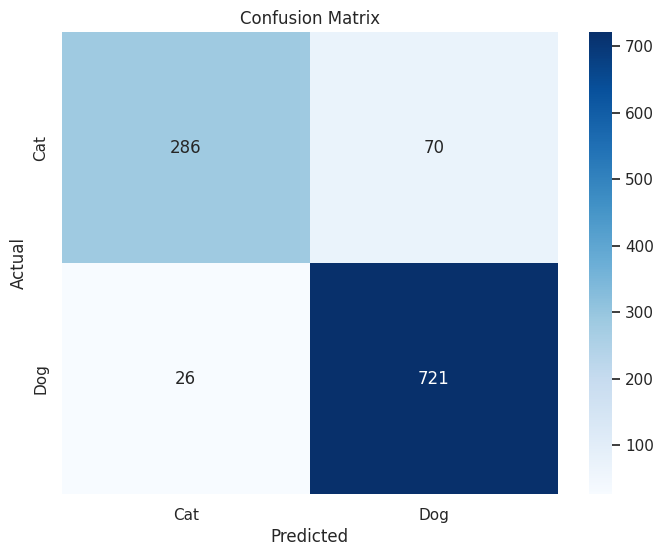

In [ ]:
all_preds = []
all_labels = []

binary_model.eval()
with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = binary_model(inputs)
    preds = (torch.sigmoid(outputs) > 0.5).float()

    all_preds.extend(preds.squeeze().cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {acc:.2%}') # 91.30%

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(cov_path + 'binary_confusion_matrix.png')
plt.show()

## Cat model evaluation

Cat Model Accuracy: 69.94%


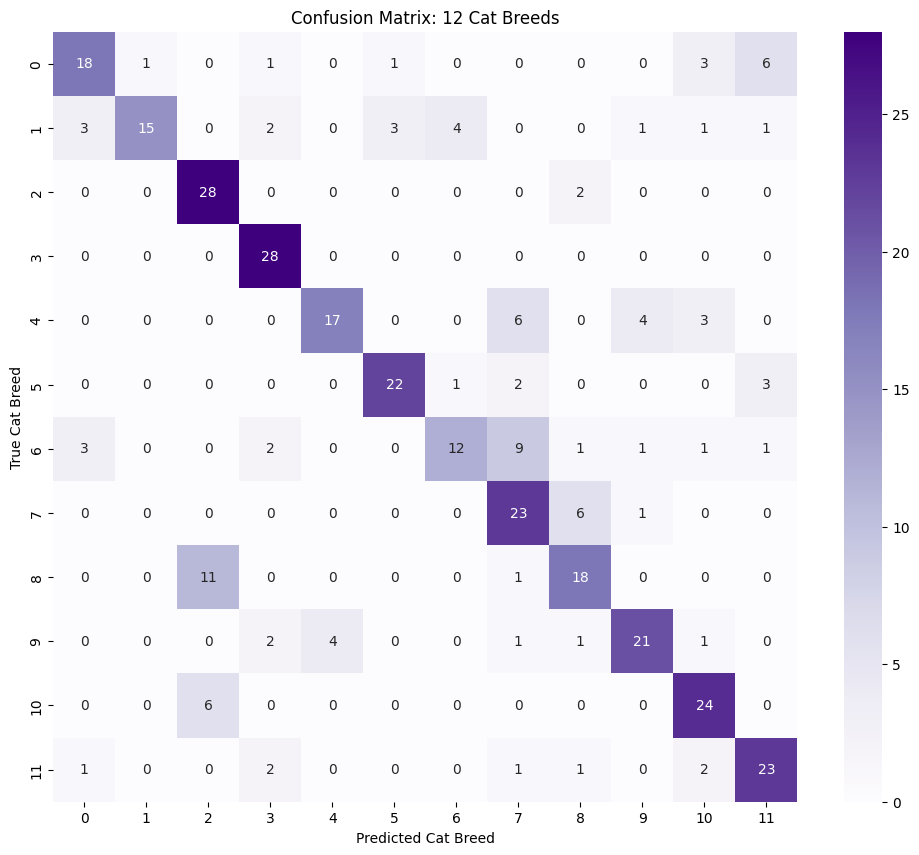

In [63]:
all_preds = []
all_labels = []

cat_model.eval()
with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = cat_model(inputs)
    _, preds = torch.max(outputs, 1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
acc = (all_preds == all_labels).mean()
print(f'Cat Model Accuracy: {acc:.2%}')

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
# cat_breeds =[...]
# xticklabels=cat_breeds, yticklabels=cat_breeds
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted Cat Breed')
plt.ylabel('True Cat Breed')
plt.title('Confusion Matrix: 12 Cat Breeds')

plt.savefig(cov_path + 'cat_confusion_matrix.png')
plt.show()

## Dog model evaluation

In [79]:
for inputs, labels in test_loader:
  print(labels)
  break

tensor([ 6, 17, 14, 17, 19, 23,  0, 14,  0, 22,  0, 14,  7, 11, 13, 17, 12, 19,
         8,  0, 22, 18,  2, 17, 21,  4, 23, 16, 18, 22, 15,  4,  4,  8, 24,  3,
        24, 13, 22,  9, 21, 19, 12, 14, 19, 17, 18,  3, 21,  3, 22, 18,  2,  0,
         4, 15, 10, 18, 13, 20,  3, 24, 16, 13])


Dog Model Test Accuracy: 64.66%


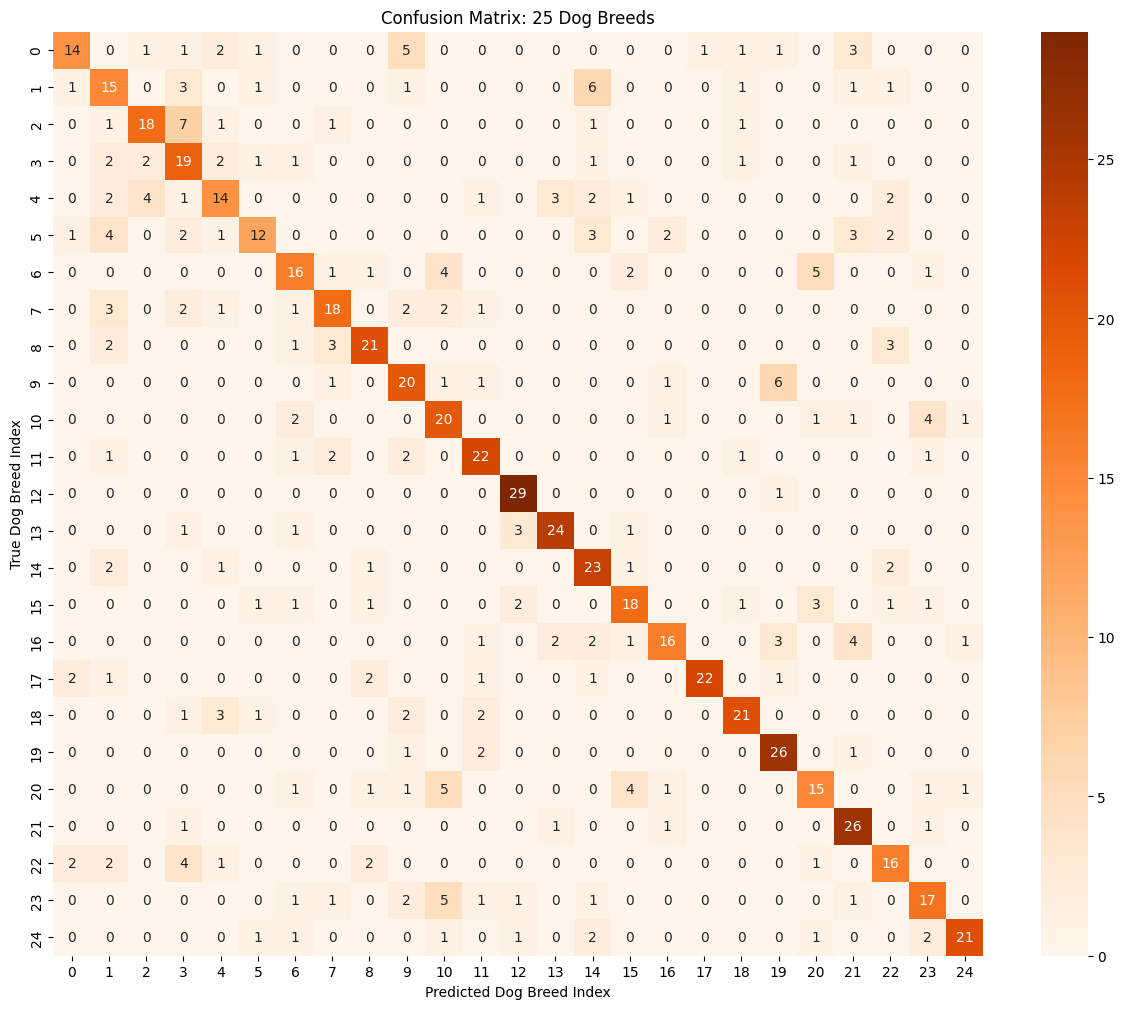

In [80]:
all_preds = []
all_labels = []

dog_model.eval()
with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = dog_model(inputs)
    _, preds = torch.max(outputs, 1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
acc = (all_preds == all_labels).mean()
print(f'Dog Model Test Accuracy: {acc:.2%}')

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted Dog Breed Index')
plt.ylabel('True Dog Breed Index')
plt.title('Confusion Matrix: 25 Dog Breeds')

plt.savefig(cov_path + 'dog_confusion_matrix.png')
plt.show()

## Pipeline evaluation

In [91]:
test_total, test_correct = 0, 0
binary_model.eval()
cat_model.eval()
dog_model.eval()

# Here labels should be - local_breed_id
with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    print(inputs.shape)
    print(labels.shape)
    print(labels)

    binary_outputs = binary_model(inputs)
    print(binary_outputs)
    # (0: cat, 1: dog)
    _, animal_type = binary_outputs.max(1)
    final_preds = torch.zeros_like(labels)

    for i in range(inputs.size(0)):
      single_input = inputs[i].unsqueeze(0)

      if animal_type[i] == 0:
        breed_outputs = cat_model(single_input)
      else:
        breed_outputs = dog_model(single_input)

      _, pred = breed_outputs.max(1)
      final_preds[i] = pred
    print(labels)
    print(final_preds)
    # break

    test_total += labels.size(0)
    test_correct += (final_preds == labels).sum().item()

print(f'Test Accuracy: {test_correct / test_total}')

torch.Size([64, 3, 224, 224])
torch.Size([64])
tensor([19,  9, 22,  8,  4, 10, 13, 16,  4,  8,  9, 11,  5,  6, 14, 16, 20, 14,
         3, 11, 13, 11,  8,  5,  3, 13,  7, 15, 14,  1, 16, 16, 23, 24, 10,  9,
         6, 11, 15, 19, 20, 23,  2, 10,  6, 13,  8,  0, 17,  9,  4,  6, 14, 24,
         1,  2,  4, 18,  9,  6, 11,  9, 17,  0], device='cuda:0')
tensor([[ 5.8649],
        [-3.1966],
        [ 8.6075],
        [ 6.4653],
        [ 5.1714],
        [ 8.3525],
        [ 2.4572],
        [ 7.5437],
        [-0.7597],
        [ 2.6335],
        [-2.8625],
        [-7.0051],
        [ 4.5131],
        [ 7.8805],
        [ 4.8871],
        [ 5.1225],
        [ 0.2392],
        [ 2.8459],
        [-0.6928],
        [-4.4148],
        [ 2.9408],
        [-3.5000],
        [-0.4237],
        [-2.9348],
        [-2.4153],
        [ 8.4076],
        [ 2.6270],
        [ 3.2113],
        [ 6.8734],
        [-8.6052],
        [ 6.0590],
        [ 4.8045],
        [ 8.8721],
        [ 9.5065],
 